In [1]:
from rltesting.torch_rl.buffers import ReplayBuffer
from dreamer import *
import gymnasium as gym
from matplotlib import pyplot as plt
from rltesting.torch_rl.utils import random_sample_single_env
from utils import WeightedAverageOverBins

import ale_py

gym.register_envs(ale_py)
env = gym.make('ALE/Pong-v5', render_mode="rgb_array")
env = gym.wrappers.ResizeObservation(env, (64, 64))

A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]


In [2]:
buffer_shapes = [(64, 64, 3), (), (), ()]
dtypes = [np.uint8, np.float32, np.float32, np.float32]
# buffer = ReplayBuffer(buffer_shapes, dtypes, buffer_size=100000)

In [3]:
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv
from rltesting.torch_rl.buffers import PerEnvBuffer
import argparse

parser = argparse.ArgumentParser(description="just a temporary argparse while I debug the world model, will be moved elsewhere later")
# specified for Atari specifically by default and using the 200M size model for Dreamer
parser.add_argument("--obs_type", default="image", choices=["image", "vector"])
encoder_parser = parser.add_argument_group("encoder")
vector_parser = parser.add_argument_group("vector")
world_model_parser = parser.add_argument_group("world_model")
encoder_parser.add_argument("--num_channels", default=3, type=int)
encoder_parser.add_argument("--image_size", default=64, type=int) # images should be square
encoder_parser.add_argument("--kernel_size", default=4, type=int) # best to keep it 4 or 6
encoder_parser.add_argument("--filter_base", default=64, type=int) # the base number of filters, which is doubled for each convolutional layer
encoder_parser.add_argument("--num_convs", default=4, type=int) # total number of convolutions, after which the dimension is size / 2^num_convs, and the final number of filters is filter_base * 2^(num_convs-1)
vector_parser.add_argument("--obs_dim", default=None, type=int)
world_model_parser.add_argument("--hidden_dim", default=1024, type=int) # hidden dims of MLPs
world_model_parser.add_argument("--hidden_state_size", default=8192, type=int) # hidden state of GRU/RSSM
world_model_parser.add_argument("--num_hiddens", default=1, type=int) # determines the depth for various MLPs
world_model_parser.add_argument("--action_dim", default=18, type=int)
world_model_parser.add_argument("--action_type", default="discrete", choices=["discrete", "continuous"])
world_model_parser.add_argument("--num_categoricals", default=32, type=int) # the number of rows in the latent
world_model_parser.add_argument("--num_codes", default=64, type=int) # the actual dim that's softmaxed over in the latent
world_model_parser.add_argument("--latent_unimix", default=0.01, type=float)
world_model_parser.add_argument("--use_block_linear", default=True, type=bool)
world_model_parser.add_argument("--act", default="silu", choices=["silu", "gelu", "relu"])
world_model_parser.add_argument("--prediction_loss_coeff", default=1, type=float)
world_model_parser.add_argument("--dynamics_loss_coeff", default=1, type=float)
world_model_parser.add_argument("--representation_loss_coeff", default=0.1, type=float)
world_model_parser.add_argument("--free_nats", default=1, type=float)
world_model_parser.add_argument("--bin_low", default=-20, type=int)
world_model_parser.add_argument("--bin_high", default=20, type=int)
parser.add_argument("--rollout_length", default=16, type=int)
parser.add_argument("--num_envs", default=30, type=int)
parser.add_argument("--world_model_batch_size", default=16, type=int)
parser.add_argument("--device", default="cuda" if torch.cuda.is_available() else "cpu")
config = parser.parse_args(args=[])
if config.act == "silu":
    config.act = nn.SiLU
elif config.act == "gelu":
    config.act = nn.GELU
elif config.act == "relu":
    config.act = nn.ReLU
if config.obs_type == "image":
    config.image_dim = (config.num_channels, config.image_size, config.image_size)
    size = config.image_size // 2 ** (config.num_convs)
    config.output_dim = (config.filter_base * 2 ** (config.num_convs - 1), size, size)
config.latent_size = config.num_categoricals * config.num_codes
config.state_size = config.hidden_state_size + config.latent_size
config.num_bins = (config.bin_high - config.bin_low) + 1 # inclusive of both high and low

def make_env(gym_id):
    def thunk():
        gym.register_envs(ale_py)
        env = gym.make(gym_id, render_mode="rgb_array")
        env = gym.wrappers.ResizeObservation(env, (64, 64))
        return env
    return thunk

num_envs = 16
env = make_vec_env(make_env('ALE/Pong-v5'), num_envs, vec_env_cls=SubprocVecEnv, vec_env_kwargs=dict(start_method='spawn'))
buffer = PerEnvBuffer(num_envs, buffer_shapes, dtypes, buffer_size=1_000_000)

A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (version 0.10.2+c9d4b19)
[Powered by Stella]
A.L.E: Arcade Learning Environment (vers

In [4]:
obs = env.reset()
for _ in range(6000):
    action = np.repeat(env.action_space.sample(), num_envs)
    next_obs, reward, done, info = env.step(action)
    buffer.add_sample_until_episode_terminal([obs, action, reward, done])
    obs = next_obs

In [5]:
worldmodel = DreamerWorldModel(config).cuda()
opt = torch.optim.Adam(worldmodel.parameters(), 4e-5)

In [ ]:
losses = []
dict_losses = {}
for i in range(1000):
    if i % 100 == 0:
        print(i)
    action = np.repeat(env.action_space.sample(), num_envs)
    next_obs, reward, done, info = env.step(action)
    buffer.add_sample_until_episode_terminal([obs, action, reward, done])
    obs = next_obs
    sample = buffer.sample(config.world_model_batch_size, 64)
    loss, loss_dict = worldmodel.world_model_loss(torch.tensor(sample[0]).float().transpose(-3, -1).cuda(),
                                        F.one_hot(torch.tensor(sample[1]).long(), 18).float().cuda(), 
                                        torch.tensor(sample[2]).cuda(), 
                                torch.tensor(sample[3]).cuda(), torch.zeros(config.world_model_batch_size, 8192).cuda())
    for k, v in loss_dict.items():
        if k in dict_losses:
            dict_losses[k].append(v)
        else:
            dict_losses[k] = [v]
    loss.backward()
    torch.nn.utils.clip_grad_norm_(worldmodel.parameters(), max_norm=0.5) 
    opt.step()
    opt.zero_grad()
    losses.append(loss.detach().cpu().numpy())

0


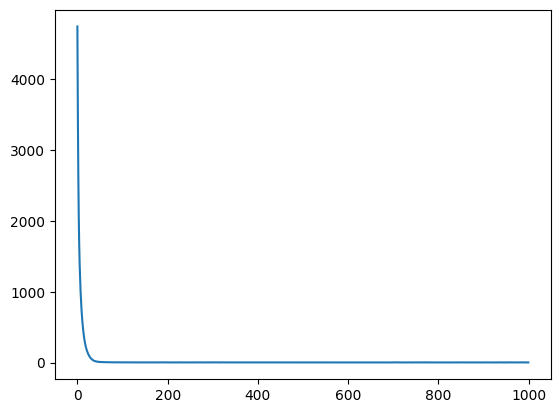

In [ ]:
plt.plot(losses)

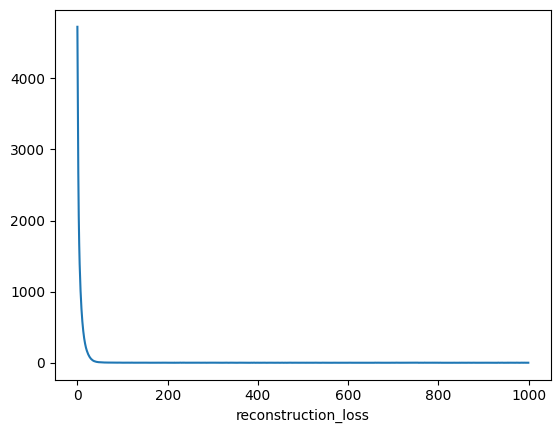

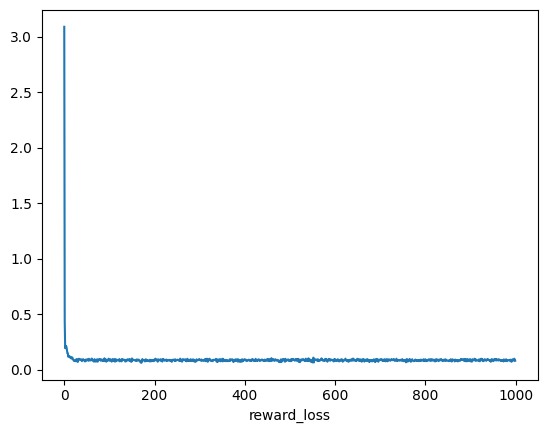

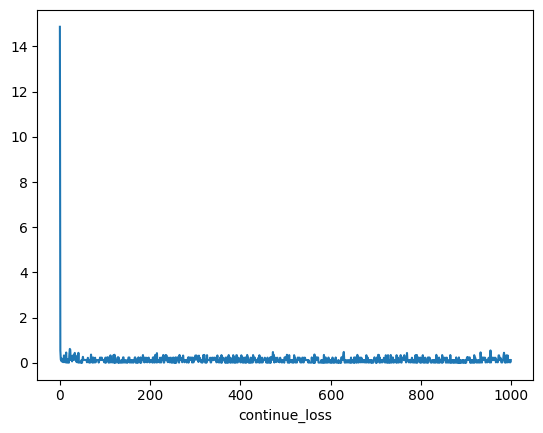

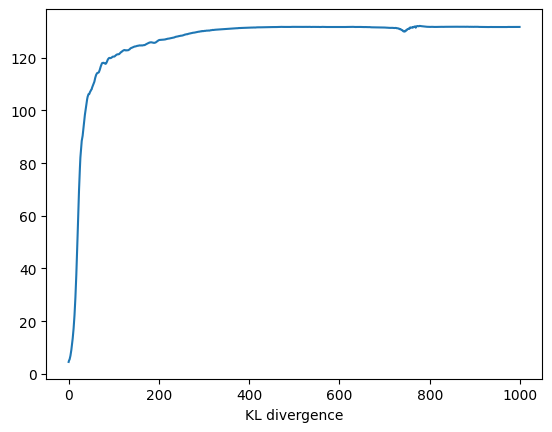

In [ ]:
for k, v in dict_losses.items():
    plt.plot(v)
    plt.xlabel(k)
    plt.show()
    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.184135..2.8505828].


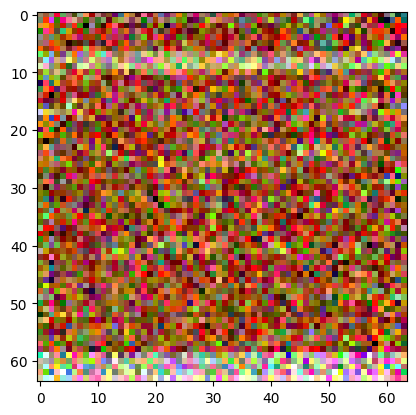

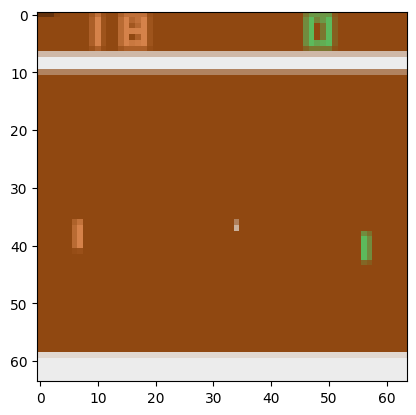

In [ ]:
i = 0

hidden = torch.zeros(config.world_model_batch_size, 8192).cuda()
transformed_obs = symlog(torch.tensor(sample[0]).float().transpose(-3, -1).cuda())
probs_enc = worldmodel.encoder(transformed_obs[i], hidden)
latent_enc = Independent(OneHotCategoricalStraightThrough(probs_enc), 1).rsample()
reconstruction = worldmodel.decoder(latent_enc, hidden)
recon_img = to_numpy(symexp(reconstruction)[0].transpose(0, 2))
recon_img = recon_img + 0.5#(recon_img - np.min(recon_img)) / (np.max(recon_img) - np.min(recon_img))
plt.imshow(recon_img)
plt.show()
plt.imshow(sample[0][i, 0])